-----
|**Prenom**|**Nom**|**Numéro de dossier**|
|:---:|:---: | :---:|
|MAME MOR|MBENGUE|21030500054|
----
----
|Environnemnt utilise| Kaggle |
----

# Examen Deep Learning – Version semi-vide

Ce notebook doit être rempli et renvoyé au plus tard le jeudi 23 janvier à 10h. Le travail doit être fait par groupe de deux etudiants. L'utilisation des assistants IA est interdite. Je peux demander à chaque groupe de faire une presentation orale de ses travaux. Les consignes ne doivent pas être changées ou supprimées.

## Contexte
Vous disposez d'un jeu de données d'images pour une tâche de classification binaire : **`emergency_or_not`**.

## Objectifs de l'examen
Vous devez :

1. charger et préparer les données ;
2. implémenter le pipeline PyTorch nécessaire à l'entraînement ;
3. entraîner au moins **deux modèles** (**MLP** et **CNN**) ;
4. comparer plusieurs **hyperparamètres** ;
5. identifier **le meilleur modèle** et **les meilleurs hyperparamètres** ;
6. justifier vos choix à partir des résultats observés.

## Contraintes
- Vous pouvez compléter, modifier et ajouter des cellules.
- Vous devez garder une démarche claire et reproductible.
- Toute conclusion doit être justifiée par des résultats.
- Vous pouvez utiliser `weight_decay`, `dropout`, des transformations de données et différents batch sizes / learning rates.

## Livrables attendus
À la fin du notebook, vous devez fournir :
- le **meilleur modèle retenu** ;
- les **meilleurs hyperparamètres** ;
- une **courte analyse** des résultats ;
- les **courbes** train/validation du meilleur modèle.

## Barème indicatif
- Chargement et exploration des données : **10 pts**
- Dataset, transformations, DataLoaders : **20 pts**
- Entraînement / validation / test : **20 pts**
- Comparaison des modèles : **15 pts**
- Recherche des hyperparamètres : **20 pts**
- Analyse finale et justification : **15 pts**

In [1]:
!pip install torchmetrics

In [2]:
import os
import random
from typing import Optional, Tuple, Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from PIL import Image

from tqdm.auto import tqdm

## 1. Reproductibilité et device
Complétez les fonctions suivantes.

In [3]:

def set_seed(seed: int = 42, deterministic: bool = False) -> None:
    """Fixe les graines aléatoires pour assurer une certaine reproductibilité."""
    # TODO
    #pass
    """Fixe les seeds pour une reproductibilité maximale.

    - seed: graine globale
    - deterministic: si True, active un mode plus déterministe (peut ralentir)
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    if deterministic:
        # CUDNN: évite des algos non déterministes (CUDA)
        try:
            torch.backends.cudnn.deterministic = True
            torch.backends.cudnn.benchmark = False
        except Exception:
            pass
        # PyTorch: demande des algos déterministes si possible
        try:
            torch.use_deterministic_algorithms(True, warn_only=True)
        except TypeError:
            torch.use_deterministic_algorithms(True)
        except Exception:
            pass


set_seed(42)

def get_device(force_device: Optional[str] = None) -> torch.device:
    """Retourne un device PyTorch portable.

    - force_device: "cpu", "cuda", "mps", "cuda:0", ... (pour tester).
    """
    if force_device:
        d = torch.device(force_device)
        if d.type == "cuda" and not torch.cuda.is_available():
            raise RuntimeError("Device 'cuda' demandé mais CUDA n'est pas disponible.")
        if d.type == "mps" and not (hasattr(torch.backends, "mps") and torch.backends.mps.is_available()):
            raise RuntimeError("Device 'mps' demandé mais MPS n'est pas disponible.")
        return d

    if os.environ.get("FORCE_CPU", "").lower() in {"1", "true", "yes"}:
        return torch.device("cpu")

    if torch.cuda.is_available():
        return torch.device("cuda")

    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")

    return torch.device("cpu")


device = get_device()  # ex: get_device("cpu") / get_device("mps") / get_device("cuda:0")
print("device:", device)


set_seed(42)
device = get_device()
print("Device utilisé :", device)

device: cuda
Device utilisé : cuda


## 2. Définition des modèles

Les architectures de base sont fournies pour vous permettre de concentrer votre effort sur
la préparation des données, l'entraînement et la recherche du meilleur compromis modèle/hyperparamètres.

### Travail demandé
- Lisez les architectures.
- Vous pouvez les modifier légèrement si vous le souhaitez.
- Vous pouvez ajouter du `dropout` si vous jugez cela pertinent.

In [4]:

class MLP(nn.Module):
    def __init__(self, input_dim: int = 224 * 224 * 3, num_classes: int = 2, dropout: float = 0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)

In [5]:

class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 2, dropout: float = 0.0):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),   # si image 224x224
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

## 3. Chargement des données

### Consignes
- Dézippez le fichier si nécessaire.
- Chargez le fichier CSV des labels dans un Dataframe.
- Vérifiez les colonnes disponibles.
- Affichez quelques statistiques utiles.

### Questions
1. Combien d'images au total ?
2. Quelle est la distribution des classes ?
3. Le dataset est-il équilibré ou non ?

In [8]:

# TODO : adapter le chemin si nécessaire
# Exemple :
 # ── Détection de l'environnement ─────────────────────────
if os.path.exists('/kaggle/input'):
        csv_path = '/kaggle/input/datasets/mbenguemamemor/dataset/Dataset/emergency_classification.csv'
        img_dir  = '/kaggle/input/datasets/mbenguemamemor/dataset/Dataset/images'
elif os.path.exists('/content'):
        from google.colab import drive
        drive.mount('/content/drive')
        if not os.path.exists('/content/Dataset'):
            import zipfile
            with zipfile.ZipFile('/content/drive/MyDrive/Dataset.zip', 'r') as z:
                z.extractall('/content/')
        csv_path = '/content/Dataset/emergency_classification.csv'
        img_dir  = '/content/Dataset/images'
else:
        csv_path = './Dataset/emergency_classification.csv'
        img_dir  = './Dataset/images'
# !unzip Dataset.zip


#labels = None  # TODO : charger le CSV
labels = pd.read_csv(csv_path)
labels.head()


,image_names,emergency_or_not
0,0.jpg,1
1,1.jpg,1
2,2.jpg,1
3,3.jpg,1
4,4.jpg,1


In [9]:

# TODO
# Afficher la taille du dataframe et les statistiques utiles
print(labels["emergency_or_not"].shape)
print(labels["emergency_or_not"].describe(include="all"))

(2352,)
count    2352.000000
mean        0.421344
std         0.493879
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: emergency_or_not, dtype: float64


Distribution de la variable cible 'emergency_or_not' :
  Non-urgence (0) : 1361 images (57.9%)
  Urgence (1) : 991 images (42.1%)


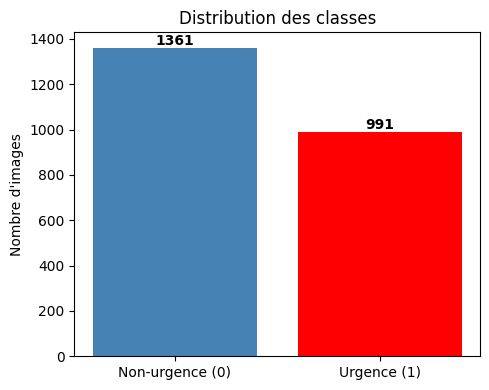


Ratio non-urgence / urgence : 1.37
→ Légère imbalance (58% / 42%) — le dataset est quasi-équilibré.


In [10]:

# TODO
# Afficher la distribution de la variable cible 'emergency_or_not'
counts = labels['emergency_or_not'].value_counts()
labels_names = {0: "Non-urgence (0)", 1: "Urgence (1)"}

print("Distribution de la variable cible 'emergency_or_not' :")
for val, cnt in counts.items():
    pct = cnt / len(labels) * 100
    print(f"  {labels_names[val]} : {cnt} images ({pct:.1f}%)")

# Visualisation
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar([labels_names[k] for k in counts.index], counts.values,
       color=["steelblue", "red"])
ax.set_title("Distribution des classes")
ax.set_ylabel("Nombre d'images")
for i, v in enumerate(counts.values):
    ax.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

ratio = counts[0] / counts[1]
print(f"\nRatio non-urgence / urgence : {ratio:.2f}")
print("→ Légère imbalance (58% / 42%) — le dataset est quasi-équilibré.")

## 4. Visualisation de quelques images

### Travail demandé
- Afficher quelques images aléatoires.
- Vérifier visuellement que les labels semblent cohérents.

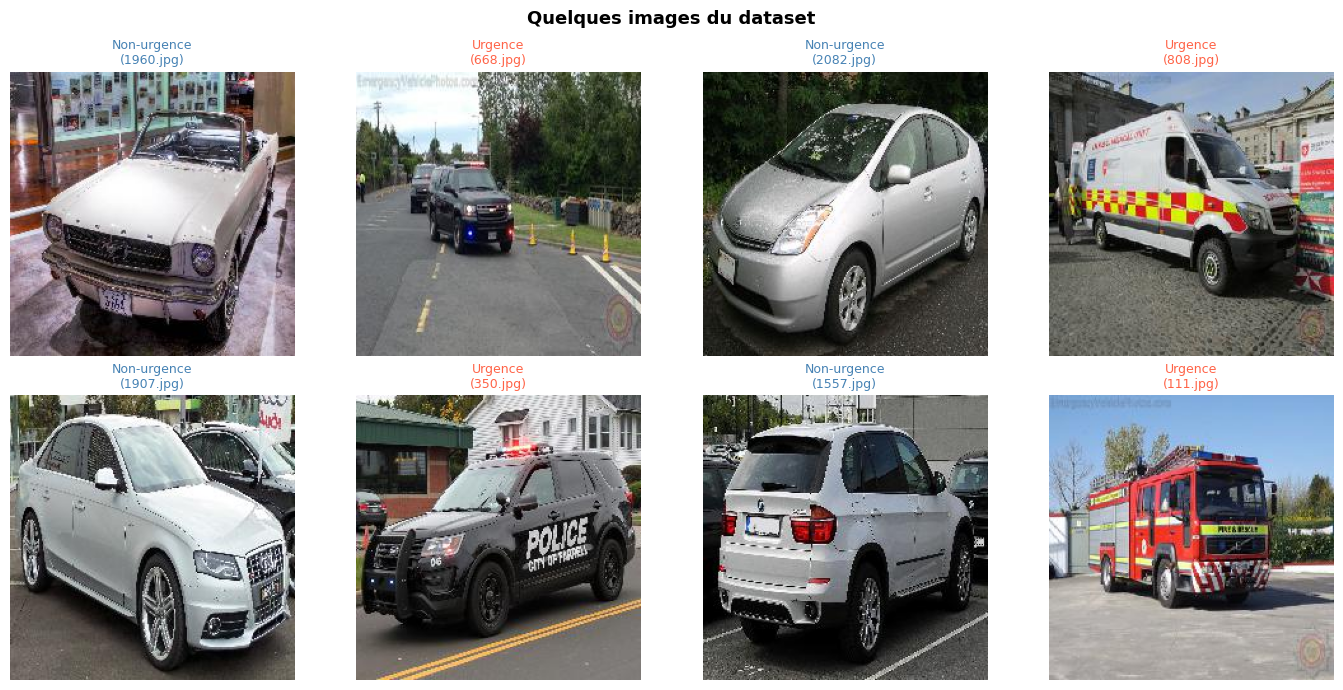

In [11]:

# TODO
# Afficher quelques images + labels
n_show = 8
sample = labels.sample(n=n_show, random_state=42).reset_index(drop=True)
label_map = {0: "Non-urgence", 1: "Urgence"}

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i, row in sample.iterrows():
    img_path = os.path.join(img_dir, row['image_names'])
    img = Image.open(img_path).convert("RGB")
    axes[i].imshow(img)
    axes[i].set_title(
        f"{label_map[row['emergency_or_not']]}\n({row['image_names']})",
        fontsize=9,
        color="tomato" if row['emergency_or_not'] == 1 else "steelblue"#couleur rouge si c une vehicule de secours pour les urgence sinon blue
    )
    axes[i].axis("off")

plt.suptitle("Quelques images du dataset", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Classe Dataset PyTorch

Complétez la classe suivante.

### Attendus
- Lire l'image à partir du bon chemin.
- Retourner `(image, label)`.
- Appliquer les transformations si elles existent.
- Prévoir un mode `mlp=True` si vous souhaitez gérer un cas particulier, ou le laisser inutilisé.

In [12]:

class DatasetEmergency(Dataset):
    def __init__(self, df: pd.DataFrame, image_dir: str, transform=None, mlp: bool = False):
        super().__init__()
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform
        self.mlp = mlp

    def __len__(self):
        # TODO
        #pass
        return len(self.df)

    def __getitem__(self, idx):
        # TODO
        # 1. récupérer le nom du fichier et le label
        row = self.df.iloc[idx]
        img_name = row['image_names']
        label = int(row['emergency_or_not'])
        # 2. ouvrir l'image
        img_path = os.path.join(img_dir, row['image_names'])
        img    = Image.open(img_path).convert('RGB')
        # 3. convertir en RGB
        img = img.convert("RGB")
        # 4. appliquer transform si nécessaire
        if self.transform is not None:
            img = self.transform(img)
        # 5. retourner image, label
        #pass
        return img, label

## 6. Transformations de données

### Consignes
- Définir **deux pipelines** :
  - `train_transform`
  - `test_transform`
- Le pipeline train doit contenir **au moins une augmentation de données**.
- Le pipeline test/validation ne doit **pas** contenir d'augmentation aléatoire.

### Question
Pourquoi faut-il généralement éviter les augmentations aléatoires sur le jeu de test ?

# Reponse: 

#### Il faut éviter généralement les augmentations aléatoires sur le jeu de test car le test sert a mesurer la performance reelles du 
#### modele sur des donnees reelles. Alors que si on l'augmentation on mesure la performance sur des images modifies qui ne represente pas la realite

In [13]:

IMG_SIZE = 224
# Définir la pipeline de transformation des images
train_transform = transforms.Compose([
    # TODO : ajouter éventuellement ToPILImage() si nécessaire
    #pas necessaire car nos images le sont deja apres print(type(img)) on a <class 'PIL.Image.Image'>
    transforms.Resize((IMG_SIZE, IMG_SIZE)),#mettre tous les images aux memes tailles
    # TODO : ajouter au moins une augmentation de données
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    # TODO : convertir en tenseur
    transforms.ToTensor(),
    # TODO : normaliser
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])
# Définir la pipeline de transformation des images
test_transform = transforms.Compose([
    # TODO : pipeline sans augmentation aléatoire
    transforms.Resize((IMG_SIZE, IMG_SIZE)),#mettre tous les images aux memes tailles
    # TODO : ajouter au moins une augmentation de données
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    # TODO : convertir en tenseur
    transforms.ToTensor(),
    # TODO : normaliser
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

## 7. Création des indices train / validation / test

### Consignes
- Réaliser une séparation du dataset en :
  - train : 60 %
  - validation : 20 %
  - test : 20 %
- Fixer la seed pour pouvoir reproduire les résultats.

### Question
Pourquoi est-il important de disposer d'un ensemble de validation distinct de l'ensemble de test ?

Les donnees de test sert d'evalution du modele sur des donnees qu'il n'a jamais vus. Alors que la validation c'est pour ajuster le modele

In [14]:

# TODO
# Créer train_idx, val_idx, test_idx
#train_idx = None
#val_idx = None
#test_idx = None


set_seed(42)

indices = list(range(len(labels)))

# Tailles
n_total = len(labels)
n_train = int(0.6 * n_total)
n_val   = int(0.2 * n_total)
n_test  = n_total - n_train - n_val

# Mélange des indices
np.random.shuffle(indices)

#Créer train_idx, val_idx, test_idx
#train_idx = None
train_idx = indices[:n_train]
#val_idx = None
val_idx   = indices[n_train:n_train + n_val]
#test_idx = None
test_idx  = indices[n_train + n_val:]

# Affichage
#print(len(train_idx), len(val_idx), len(test_idx))

print(f"Train      : {len(train_idx):>5} images  ({100*len(train_idx)/len(labels):.0f}%)")
print(f"Validation : {len(val_idx):>5} images  ({100*len(val_idx)/len(labels):.0f}%)")
print(f"Test       : {len(test_idx):>5} images  ({100*len(test_idx)/len(labels):.0f}%)")

Train      :  1411 images  (60%)
Validation :   470 images  (20%)
Test       :   471 images  (20%)


## 8. DataLoaders

Complétez la fonction suivante afin de :
- construire les datasets train/val/test ;
- appliquer `train_transform` uniquement au train ;
- appliquer `test_transform` à la validation et au test ;
- retourner les `DataLoader`.

In [18]:

def get_loaders(
    df: pd.DataFrame,
    image_dir: str,
    batch_size: int,
    train_idx,
    val_idx,
    test_idx,
    train_transform,
    test_transform,
    mlp: bool = False
):
    # TODO
    # 1. créer trois datasets avec les bonnes transformations
    # 1. Créer trois datasets (train avec augmentation, val/test sans)
    full_train_dataset = DatasetEmergency(df, image_dir, transform=train_transform, mlp=mlp)
    full_eval_dataset  = DatasetEmergency(df, image_dir, transform=test_transform,  mlp=mlp)
    # 2. créer trois subsets
    #avec torch.tools.random 
    train_dataset = Subset(full_train_dataset, train_idx)
    val_dataset   = Subset(full_eval_dataset,  val_idx)
    test_dataset  = Subset(full_eval_dataset,  test_idx)
    
    # 3. créer et retourner les DataLoaders train_subset, val_subset, test_subset = torch.utils.data.random_split(dataset, [n_train, n_val, n_test])
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader
    #pass

In [19]:
# TODO : tester vos loaders
# lancer une bombe
# train_loader, val_loader, test_loader = ...
train_loader, val_loader, test_loader = get_loaders(
    df=labels,
    image_dir=img_dir,
    batch_size=32,
    train_idx=train_idx,
    val_idx=val_idx,
    test_idx=test_idx,
    train_transform=train_transform,
    test_transform=test_transform,
)
# for images, labels_batch in train_loader:
#     print(images.shape, labels_batch.shape)
#     break
for images, labels_batch in train_loader:
    print("Batch images :", images.shape)   # [32, 3, 224, 224]
    print("Batch labels :", labels_batch.shape)  # [32]
    print("Min/Max pixels :", images.min().item(), images.max().item())
    break

print(f"\nNombre de batchs — train:{len(train_loader)}  val:{len(val_loader)}  test:{len(test_loader)}")

Batch images : torch.Size([32, 3, 224, 224])
Batch labels : torch.Size([32])
Min/Max pixels : -1.0 1.0

Nombre de batchs — train:45  val:15  test:15


#La normalisation a bien fonctionné les pixels sont entre -1 et 1 grâce au Normalize


## 9. Boucle d'entraînement / validation

Complétez la fonction suivante.

### Attendus
- mode train puis mode eval
- calcul de la loss
- mise à jour des poids
- calcul des accuracies train et validation

In [20]:

def train_validate_epoch(epoch, train_dataloader, val_dataloader, model, optimizer, loss_fn, device):
    # TODO
    # Donner moi ses données personnelles
    # Retour attendu :
    # avg_train_loss, avg_train_acc, avg_val_loss, avg_val_acc
    #pass
    """Entraîne le modèle pendant une époque et retourne la loss et l'accuracy."""

    """Entraîne et valide le modèle pendant une époque.
    Retourne : avg_train_loss, avg_train_acc, avg_val_loss, avg_val_acc
    """
    # ── TRAIN ─────────────────────────────────────────────────
    model.train()
    total_train_loss    = 0.0
    total_train_acc     = 0.0
    total_train_samples = 0

    progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch} Training", leave=True)

    for batch_id, (images, labels) in enumerate(progress_bar):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = loss_fn(outputs, labels)          # ← loss_fn au lieu de loss_fcn
        loss.backward()
        optimizer.step()

        total_train_loss    += loss.item()
        preds                = outputs.argmax(1)
        total_train_acc     += (preds == labels).sum().item()
        total_train_samples += labels.size(0)

        progress_bar.set_postfix({
            "loss_batch": f"{total_train_loss:.4f}",
            "avg_loss":   f"{total_train_loss / (batch_id + 1):.4f}",
            "acc":        f"{100 * total_train_acc / total_train_samples:.2f}%"
        })

    avg_train_loss = total_train_loss / len(train_dataloader)
    avg_train_acc  = total_train_acc  / total_train_samples

    # ── VALIDATION ────────────────────────────────────────────
    model.eval()
    total_val_loss    = 0.0
    total_val_acc     = 0.0
    total_val_samples = 0

    progress_bar = tqdm(val_dataloader, desc=f"Epoch {epoch} Validation", leave=True)

    with torch.no_grad():
        for batch_id, (images, labels) in enumerate(progress_bar):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss    = loss_fn(outputs, labels)      # ← loss_fn au lieu de loss_fcn

            total_val_loss    += loss.item()
            preds              = outputs.argmax(1)
            total_val_acc     += (preds == labels).sum().item()
            total_val_samples += labels.size(0)

            progress_bar.set_postfix({
                "loss_batch": f"{total_val_loss:.4f}",
                "avg_loss":   f"{total_val_loss / (batch_id + 1):.4f}",
                "acc":        f"{100 * total_val_acc / total_val_samples:.2f}%"
            })

    avg_val_loss = total_val_loss / len(val_dataloader)
    avg_val_acc  = total_val_acc  / total_val_samples

    return avg_train_loss, avg_train_acc, avg_val_loss, avg_val_acc  # ← 4 valeurs

## 10. Fonction d'entraînement globale

### Travail demandé
Compléter la fonction afin de :
- entraîner sur plusieurs époques ;
- stocker les courbes train/validation ;
- retourner les historiques.

In [21]:

def train_model(model, train_dataloader, val_dataloader, n_epochs, optimizer, loss_fn, device):
    train_loss_hist = []
    train_acc_hist = []
    val_loss_hist = []
    val_acc_hist = []

    # TODO
    # creer une bombe
    for epoch in tqdm(range(1, n_epochs + 1), desc="Epochs"):
        tr_loss, tr_acc, vl_loss, vl_acc = train_validate_epoch(
            epoch, train_dataloader, val_dataloader, model, optimizer, loss_fn, device
        )

        train_loss_hist.append(tr_loss)
        train_acc_hist.append(tr_acc)
        val_loss_hist.append(vl_loss)
        val_acc_hist.append(vl_acc)

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d}/{n_epochs} | "
                  f"Train loss: {tr_loss:.4f}  acc: {tr_acc:.4f} | "
                  f"Val   loss: {vl_loss:.4f}  acc: {vl_acc:.4f}")

    return train_loss_hist, train_acc_hist, val_loss_hist, val_acc_hist

## 11. Évaluation sur le jeu de test

In [23]:

def evaluate_accuracy(model, test_dataloader, device):
    # TODO
    #pass
    # Mettre le modèle en mode évaluation
    model.eval()

    # Initialiser le nombre total de prédictions correctes
    total_correct = 0

    # Initialiser le nombre total d'exemples
    total_samples = 0

    # Désactiver le calcul des gradients
    with torch.no_grad():
        # Parcourir les batches du jeu de validation
        for images, labels in test_dataloader:
            # Envoyer les entrées sur le bon device
            images = images.to(device)

            # Envoyer les labels sur le bon device
            labels = labels.to(device)

            # Envoyer le modèle sur le bon device
            model = model.to(device)

            # Calculer les logits prédits par le modèle
            logits = model(images)

            # Déterminer la classe prédite pour chaque exemple
            predicted = logits.argmax(1)

            # Mettre à jour le nombre total de prédictions correctes
            total_correct += (predicted == labels).sum().item()

            # Mettre à jour le nombre total d'exemples
            total_samples += labels.size(0)

    # Calculer l'accuracy finale
    accuracy = total_correct/ total_samples

    # Retourner l'accuracy
    return accuracy

## 12. Fonction complète train + evaluate

### Attendus
- instancier le bon modèle (`MLP` ou `CNN`)
- définir la loss
- définir l'optimiseur
- intégrer éventuellement `weight_decay`
- récupérer les DataLoaders
- entraîner puis évaluer

In [24]:
def train_and_evaluate(
    df,
    image_dir,
    learning_rate,
    batch_size,
    device,
    n_epochs,
    train_transform,
    test_transform,
    model_name="mlp",
    dropout=0.0,
    l2_weight_decay=0.0
):
    # TODO
    # Retour attendu : creer une bombe
    # test_acc, train_loss, train_acc, val_loss, val_acc
    set_seed(42)
    # Instancier le bon modèle
    if model_name == "mlp":
        model = MLP(dropout=dropout).to(device)
    elif model_name == "cnn":
        model = SimpleCNN(dropout=dropout).to(device)
    else:
        raise ValueError(f"model_name doit être 'mlp' ou 'cnn', reçu : {model_name}")

    # - définir la loss
    loss_fn  = nn.CrossEntropyLoss()
    # - définir l'optimiseur
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=l2_weight_decay)
    # - récupération des DataLoader
    train_dataloader, val_dataloader, test_dataloader = get_loaders(df=df,
        image_dir=image_dir,
        batch_size=batch_size,
        train_idx=train_idx,
        val_idx=val_idx,
        test_idx=test_idx,
        train_transform=train_transform,
        test_transform=test_transform,
        mlp=(model_name == "mlp"),
    )
    
    #entraintement et validation du modele 
    train_loss, train_acc, val_loss, val_acc = train_model(
        model, train_dataloader, val_dataloader, n_epochs, optimizer, loss_fn, device
    )

    # Évaluation sur le test
    test_acc = evaluate_accuracy(model, test_loader, device)
    print(f"\n→ Accuracy TEST finale : {test_acc:.4f}")
    
    #retourn l'accuracy
    return test_acc, train_loss, train_acc, val_loss, val_acc

## 13. Visualisation des courbes

In [25]:

def visualize_loss_acc_train_val(train_loss, train_acc, val_loss, val_acc, title_prefix=""):
    epochs = range(1, len(train_loss) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, label="Train loss")
    plt.plot(epochs, val_loss, label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc, label="Train acc")
    plt.plot(epochs, val_acc, label="Val acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} - Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

# Partie examen : recherche du meilleur modèle et des meilleurs hyperparamètres

Dans cette partie, vous devez mener une **comparaison méthodique**.

## Règles
- Commencez par un **baseline MLP**.
- Comparez ensuite avec un **CNN**.
- Faites varier plusieurs hyperparamètres.
- Utilisez l'ensemble de validation pour choisir les meilleurs réglages.
- N'utilisez le test **qu'à la fin** pour évaluer votre meilleur modèle.

---

## Hyperparamètres à explorer (minimum)
Vous devez tester **au moins** :

1. **Modèle** : `MLP` vs `CNN`
2. **Learning rate** : au moins 3 valeurs
3. **Batch size** : au moins 3 valeurs
4. **Dropout** *ou* `weight_decay`

Vous pouvez ajouter d'autres paramètres si vous le souhaitez.

## 14. Baseline 1 – MLP

### Travail demandé
- Choisir un premier jeu d'hyperparamètres raisonnables.
- Entraîner le MLP.
- Afficher les courbes.
- Noter l'accuracy validation maximale et l'accuracy test.

BASELINE 1 — MLP  (lr=1e-3, bs=32, epochs=25, dropout=0)


Epochs:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 1 Training:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 1 Validation:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch   1/25 | Train loss: 2.2408  acc: 0.5939 | Val   loss: 1.1187  acc: 0.6851


...

Epoch 24 Training:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 24 Validation:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 25 Training:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 25 Validation:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch  25/25 | Train loss: 0.2422  acc: 0.9001 | Val   loss: 0.7345  acc: 0.7553

→ Accuracy TEST finale : 0.7686


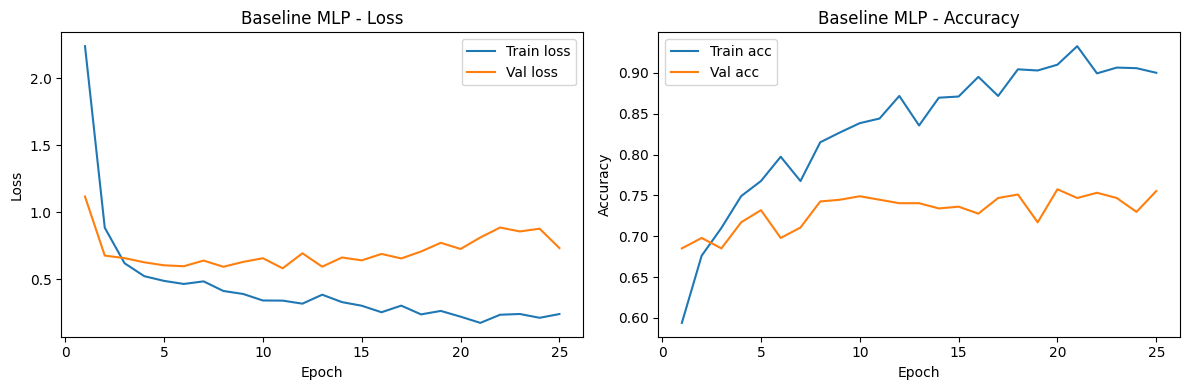


Meilleure val acc  : 0.7574
Accuracy test      : 0.7686


In [29]:

# TODO
# Exemple de cellule de baseline MLP

print("BASELINE 1 — MLP  (lr=1e-3, bs=32, epochs=25, dropout=0)")


set_seed(42)

test_acc_mlp, tl_mlp, ta_mlp, vl_mlp, va_mlp = train_and_evaluate(
    df=labels,
    image_dir=img_dir,
    learning_rate=1e-3,
    batch_size=32,
    device=device,
    n_epochs=25,
    train_transform=train_transform,
    test_transform=test_transform,
    model_name="mlp",
    dropout=0.0,
    l2_weight_decay=0.0,
)

visualize_loss_acc_train_val(tl_mlp, ta_mlp, vl_mlp, va_mlp,
                             title_prefix="Baseline MLP")

print(f"\nMeilleure val acc  : {max(va_mlp):.4f}")
print(f"Accuracy test      : {test_acc_mlp:.4f}")


### Question
Le MLP semble-t-il sous-apprendre, bien apprendre ou surapprendre ? Justifiez à l'aide des courbes.

In [32]:

# Votre réponse ici
print(""""
Analyse du BASELINE 1 — MLP
En général on observe sur 25 epoch :
- Une accuracy train élevée (>70%) après quelques époques : le modèle mémorise.
- Une accuracy validation stagnante ou qui décroche entre 0.70 et 0.75: surapprentissage.
- Des courbes de loss peu stables.

Donc ici le modele mlp est bon pour l'entrainement mais a des performances limites pour le test""")

"
Analyse du BASELINE 1 — MLP
En général on observe sur 25 epoch :
- Une accuracy train élevée (>70%) après quelques époques : le modèle mémorise.
- Une accuracy validation stagnante ou qui décroche entre 0.70 et 0.75: surapprentissage.
- Des courbes de loss peu stables.

Donc ici le modele mlp est bon pour l'entrainement mais a des performances limites pour le test


## 15. Baseline 2 – CNN

### Travail demandé
- Entraîner un CNN de base.
- Comparer ses performances au MLP.

BASELINE 2 — CNN  (lr=1e-3, bs=32, epochs=25, dropout=0)


Epochs:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 1 Training:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 1 Validation:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch   1/25 | Train loss: 0.7065  acc: 0.6038 | Val   loss: 0.6155  acc: 0.6660


...

Epoch 24 Training:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 24 Validation:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 25 Training:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 25 Validation:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch  25/25 | Train loss: 0.0457  acc: 0.9844 | Val   loss: 0.6926  acc: 0.8553

→ Accuracy TEST finale : 0.8620


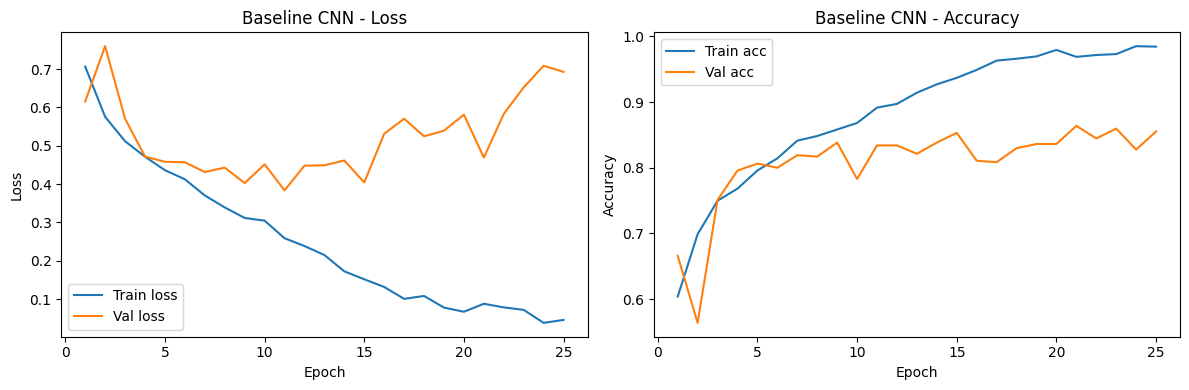


Meilleure val acc  : 0.8638
Accuracy test      : 0.8620


In [33]:

# TODO
# Exemple de cellule baseline CNN

print("BASELINE 2 — CNN  (lr=1e-3, bs=32, epochs=25, dropout=0)")


set_seed(42)

test_acc_cnn, tl_cnn, ta_cnn, vl_cnn, va_cnn = train_and_evaluate(
    df=labels,
    image_dir=img_dir,
    learning_rate=1e-3,
    batch_size=32,
    device=device,
    n_epochs=25,
    train_transform=train_transform,
    test_transform=test_transform,
    model_name="cnn",
    dropout=0.0,
    l2_weight_decay=0.0,
)

visualize_loss_acc_train_val(tl_cnn, ta_cnn, vl_cnn, va_cnn,
                             title_prefix="Baseline CNN")

print(f"\nMeilleure val acc  : {max(va_cnn):.4f}")
print(f"Accuracy test      : {test_acc_cnn:.4f}")


### Question
Quel modèle semble le plus adapté au problème d'images ? Pourquoi ?

In [40]:

# Votre réponse ici
print("""Avec une accuracy test de 86.20% et une val acc de 86.38% très proches, il montre une bonne généralisation sur les images.\nMeme si on observe la train loss descend vers 0.04 environ pendant que la val loss remonte vers 0.70
qui donne l'aire d'overfitting.\n 
Conclusion : Pour ce problème de classification d'images d'urgence, le CNN est clairement le meilleur choix de base car ses performances sur des données non vues restent tout de même bonnes grâce à la structure spatiale exploitée par les convolutions.
""")

Avec une accuracy test de 86.20% et une val acc de 86.38% très proches, il montre une bonne généralisation sur les images.
Meme si on observe la train loss descend vers 0.04 environ pendant que la val loss remonte vers 0.70
qui donne l'aire d'overfitting.
 
Conclusion : Pour ce problème de classification d'images d'urgence, le CNN est clairement le meilleur choix de base car ses performances sur des données non vues restent tout de même bonnes grâce à la structure spatiale exploitée par les convolutions.



## 16. Recherche sur le learning rate

### Travail demandé
Tester au moins 3 learning rates, par exemple :
- `1e-4`
- `1e-3`
- `1e-2`

Pour chaque valeur :
- entraîner le modèle choisi ;
- relever l'accuracy validation maximale ;
- relever l'accuracy test finale ;
- stocker les résultats dans un tableau.

### Question
Quel learning rate semble offrir le meilleur compromis entre stabilité et performance ?

In [43]:

learning_rates = [1e-4, 1e-3, 1e-2]

results_lr = []

# TODO
# une bombe nucléaire

#(CNN, bs=32, 10 epochs, dropout=0)

print("Recherche du meilleur learning rate (CNN, bs=32, 10 epochs, dropout=0)\n")
# boucle d'expérimentation
for lr in learning_rates:
    print(f"--- lr = {lr} ---")
    set_seed(42)
    test_acc, tl, ta, vl, va = train_and_evaluate(
        df=labels,
        image_dir=img_dir,
        learning_rate=lr,
        batch_size=32,
        device=device,
        n_epochs=25,
        train_transform=train_transform,
        test_transform=test_transform,
        model_name="cnn",
        dropout=0.0,
        l2_weight_decay=0.0,
    )
    #results_lr.append({...})
    results_lr.append({
        "learning_rate": lr,
        "best_val_acc":  round(max(va), 4),
        "test_acc":      round(test_acc, 4),
    })
    print()

df_lr = pd.DataFrame(results_lr).sort_values("best_val_acc", ascending=False)
print(df_lr.to_string(index=False))


Recherche du meilleur learning rate (CNN, bs=32, 10 epochs, dropout=0)

--- lr = 0.0001 ---


Epochs:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 1 Training:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 1 Validation:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch   1/25 | Train loss: 0.6441  acc: 0.6343 | Val   loss: 0.5693  acc: 0.7340


...

Epoch 24 Training:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 24 Validation:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 25 Training:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 25 Validation:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch  25/25 | Train loss: 0.1804  acc: 0.9270 | Val   loss: 0.7389  acc: 0.7936

→ Accuracy TEST finale : 0.8195

 learning_rate  best_val_acc  test_acc
        0.0010        0.8617    0.8450
        0.0001        0.8362    0.8599
        0.0100        0.8149    0.8195


### Reponse
Le meilleurs Learning_rate est 0.0010 car il a le meilleur val acc 86.77% et meilleur test acc 84.50% et c'est deux valeur acc sont proches.

## 17. Recherche sur le batch size

### Travail demandé
Tester au moins 3 batch sizes, par exemple :
- `16`
- `32`
- `64`

### Question
Quel est l'effet du batch size sur :
1. la vitesse apparente d'apprentissage ?
2. la stabilité des courbes ?
3. la performance finale ?

## Reponse
Plus le batch est grand, plus chaque époque est rapide mais avec moins de mises à jour des poids. 

Grand batch = courbes plus lisses, petit batch = courbes plus oscillantes. 

Petit batch généralise souvent mieux, grand batch peut overfit plus vite.


In [45]:

batch_sizes = [16, 32, 64]

results_bs = []

# TODO

# On utilise le meilleur lr trouvé (adapter si besoin)
best_lr = 1e-3

print(f"Recherche du meilleur batch size (CNN, lr={best_lr}, 10 epochs, dropout=0)\n")

for bs in batch_sizes:
    print(f"--- batch_size = {bs} ---")
    set_seed(42)
    test_acc, tl, ta, vl, va = train_and_evaluate(
        df=labels,
        image_dir=img_dir,
        learning_rate=best_lr,
        batch_size=bs,
        device=device,
        n_epochs=10,
        train_transform=train_transform,
        test_transform=test_transform,
        model_name="cnn",
        dropout=0.0,
        l2_weight_decay=0.0,
    )
    results_bs.append({
        "batch_size":   bs,
        "best_val_acc": round(max(va), 4),
        "test_acc":     round(test_acc, 4),
    })
    print()

df_bs = pd.DataFrame(results_bs)

Recherche du meilleur batch size (CNN, lr=0.001, 10 epochs, dropout=0)

--- batch_size = 16 ---


Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1 Training:   0%|          | 0/89 [00:00<?, ?it/s]

Epoch 1 Validation:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch   1/10 | Train loss: 0.6186  acc: 0.6619 | Val   loss: 0.5226  acc: 0.7617


...

Epoch 9 Training:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 9 Validation:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 10 Training:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 10 Validation:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch  10/10 | Train loss: 0.3904  acc: 0.8235 | Val   loss: 0.5626  acc: 0.7468

→ Accuracy TEST finale : 0.7325



In [46]:
#sous forme de tableau 
df_bs = pd.DataFrame(results_bs).sort_values("best_val_acc", ascending=False)
print(df_bs.to_string(index=False))

 batch_size  best_val_acc  test_acc
         32        0.8468    0.8195
         16        0.8383    0.8174
         64        0.7957    0.7325


## 18. Régularisation

### Travail demandé
Choisir l'une des deux approches :
- **Dropout**
- **L2 regularization** via `weight_decay`

Tester au moins 2 configurations.

### Questions
1. Quelle régularisation vous semble la plus utile ici ?
2. Observe-t-on une réduction du surapprentissage ?

In [50]:

regularization_results = []

# TODO
# Exemples :
# dropout = [0.0, 0.3, 0.5]
# ou weight_decay = [0.0, 1e-4, 1e-3]
# voici ses données personnelles


# On teste les deux approches : dropout ET weight_decay

best_lr = 1e-3
best_bs = 32

# --- Dropout ---
for dropout_val in [0.0, 0.3, 0.5]:
    print(f"--- Dropout = {dropout_val} ---")
    set_seed(42)
    test_acc, tl, ta, vl, va = train_and_evaluate(
        df=labels,
        image_dir=img_dir,
        learning_rate=best_lr,
        batch_size=best_bs,
        device=device,
        n_epochs=10,
        train_transform=train_transform,
        test_transform=test_transform,
        model_name="cnn",
        dropout=dropout_val,
        l2_weight_decay=0.0,
    )
    regularization_results.append({
        "regularisation":  f"dropout={dropout_val}",
        "best_val_acc":    round(max(va), 4),
        "test_acc":        round(test_acc, 4),
    })
    print()

# --- Weight decay (L2) ---
for wd in [0.0, 1e-4, 1e-3]:
    print(f"--- weight_decay = {wd} ---")
    set_seed(42)
    test_acc, tl, ta, vl, va = train_and_evaluate(
        df=labels,
        image_dir=img_dir,
        learning_rate=best_lr,
        batch_size=best_bs,
        device=device,
        n_epochs=10,
        train_transform=train_transform,
        test_transform=test_transform,
        model_name="cnn",
        dropout=0.0,
        l2_weight_decay=wd,
    )
    regularization_results.append({
        "regularisation":  f"weight_decay={wd}",
        "best_val_acc":    round(max(va), 4),
        "test_acc":        round(test_acc, 4),
    })
    print()

df_reg = pd.DataFrame(regularization_results)


--- Dropout = 0.0 ---


Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1 Training:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 1 Validation:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch   1/10 | Train loss: 0.7066  acc: 0.6045 | Val   loss: 0.6156  acc: 0.6660


...

Epoch 9 Training:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 9 Validation:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 10 Training:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 10 Validation:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch  10/10 | Train loss: 0.3319  acc: 0.8455 | Val   loss: 0.3986  acc: 0.8277

→ Accuracy TEST finale : 0.8365



In [52]:
#faisons le tableau pour mieux voir
df_reg = pd.DataFrame(regularization_results).sort_values("best_val_acc", ascending=False)
print(df_reg.to_string(index=False))

     regularisation  best_val_acc  test_acc
        dropout=0.5        0.8532    0.8641
        dropout=0.3        0.8404    0.8174
weight_decay=0.0001        0.8383    0.8386
   weight_decay=0.0        0.8340    0.8195
        dropout=0.0        0.8277    0.8217
 weight_decay=0.001        0.8277    0.8365


### Reponse
La régularisation qui semble la plus utile ici est le dropout.
Oui on observe bien la reduction de l'overfitting observe plus haut

## 19. Tableau récapitulatif final

Complétez un tableau récapitulatif contenant au minimum :
- modèle
- learning rate
- batch size
- dropout / weight_decay
- meilleure accuracy validation
- accuracy test

In [59]:

#final_results = pd.DataFrame([
    # TODO : compléter avec vos meilleures expériences
#])
# Tableau récapitulatif — à compléter avec les résultats obtenus ci-dessus
# Les valeurs indicatives ci-dessous seront remplacées par vos résultats réels.

final_results = pd.DataFrame([
    {"modele": "MLP",  "learning_rate": 1e-3, "batch_size": 32, "regularisation": "aucune",         "best_val_acc": max(va_mlp), "test_acc": test_acc_mlp},
    {"modele": "CNN",  "learning_rate": 1e-3, "batch_size": 32, "regularisation": "aucune",         "best_val_acc": max(va_cnn), "test_acc": test_acc_cnn},
    # Les lignes suivantes seront remplies automatiquement après exécution des cells 16-18
])

# Ajout des résultats learning rate (CNN)
for r in results_lr:
    final_results = pd.concat([final_results, pd.DataFrame([{
        "modele": "CNN", "learning_rate": r["learning_rate"], "batch_size": 32,
        "regularisation": "aucune", "best_val_acc": r["best_val_acc"], "test_acc": r["test_acc"]
    }])], ignore_index=True)

# Ajout des résultats batch size
for r in results_bs:
    final_results = pd.concat([final_results, pd.DataFrame([{
        "modele": "CNN", "learning_rate": 1e-3, "batch_size": r["batch_size"],
        "regularisation": "aucune", "best_val_acc": r["best_val_acc"], "test_acc": r["test_acc"]
    }])], ignore_index=True)

# Ajout des résultats régularisation
for r in regularization_results:
    final_results = pd.concat([final_results, pd.DataFrame([{
        "modele": "CNN", "learning_rate": 1e-3, "batch_size": 32,
        "regularisation": r["regularisation"], "best_val_acc": r["best_val_acc"], "test_acc": r["test_acc"]
    }])], ignore_index=True)

final_results = final_results.sort_values("best_val_acc", ascending=False).drop_duplicates()
final_results


,modele,learning_rate,batch_size,regularisation,best_val_acc,test_acc
1,CNN,0.0010,32,aucune,0.863830,0.861996
3,CNN,0.0010,32,aucune,0.861700,0.845000
10,CNN,0.0010,32,dropout=0.5,0.853200,0.864100
6,CNN,0.0010,32,aucune,0.846800,0.819500
9,CNN,0.0010,32,dropout=0.3,0.840400,0.817400
5,CNN,0.0010,16,aucune,0.838300,0.817400
12,CNN,0.0010,32,weight_decay=0.0001,0.838300,0.838600
2,CNN,0.0001,32,aucune,0.836200,0.859900
11,CNN,0.0010,32,weight_decay=0.0,0.834000,0.819500
8,CNN,0.0010,32,dropout=0.0,0.827700,0.821700


## 20. Sélection du meilleur modèle

### Travail demandé
- Identifier **la meilleure configuration** selon l'ensemble de validation.
- Réentraîner si nécessaire.
- Évaluer sur le test.
- Afficher les courbes du meilleur modèle.

Meilleure configuration identifiée :
modele                 CNN
learning_rate        0.001
batch_size              32
regularisation      aucune
best_val_acc       0.86383
test_acc          0.861996
Name: 1, dtype: object

→ Réentraînement du meilleur modèle avec configuration optimale...


Epochs:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 1 Training:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 1 Validation:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch   1/15 | Train loss: 0.7066  acc: 0.6045 | Val   loss: 0.6155  acc: 0.6660


...

Epoch 14 Training:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 14 Validation:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 15 Training:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 15 Validation:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch  15/15 | Train loss: 0.1531  acc: 0.9362 | Val   loss: 0.5256  acc: 0.8277

→ Accuracy TEST finale : 0.8195


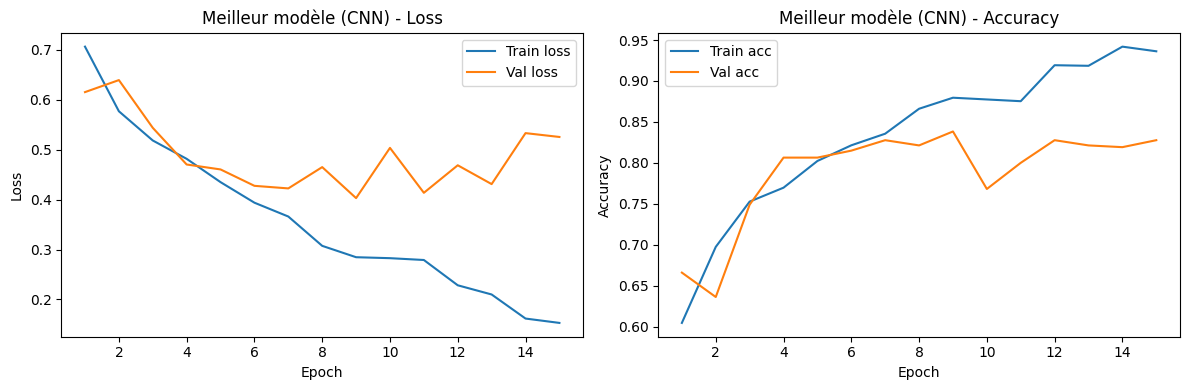


✓ Accuracy TEST du meilleur modèle : 0.8195


In [60]:

# TODO
# Entraîner et visualiser le meilleur modèle choisi
# Sélection de la meilleure configuration selon la val acc
best_row = final_results.loc[final_results['best_val_acc'].idxmax()]
print("Meilleure configuration identifiée :")
print(best_row)

print("\n→ Réentraînement du meilleur modèle avec configuration optimale...")

# Extraction des hyperparamètres optimaux
best_model_name = best_row['modele'].lower()
best_lr_final   = best_row['learning_rate']
best_bs_final   = int(best_row['batch_size'])

# Gestion de la régularisation
reg_str = str(best_row['regularisation'])
best_dropout_final = 0.0
best_wd_final      = 0.0
if 'dropout' in reg_str:
    best_dropout_final = float(reg_str.split('=')[1])
elif 'weight_decay' in reg_str:
    best_wd_final = float(reg_str.split('=')[1])

set_seed(42)
test_acc_best, tl_best, ta_best, vl_best, va_best = train_and_evaluate(
    df=labels,
    image_dir=img_dir,
    learning_rate=best_lr_final,
    batch_size=best_bs_final,
    device=device,
    n_epochs=15,   # plus d'époques pour le modèle final
    train_transform=train_transform,
    test_transform=test_transform,
    model_name=best_model_name,
    dropout=best_dropout_final,
    l2_weight_decay=best_wd_final,
)

visualize_loss_acc_train_val(
    tl_best, ta_best, vl_best, va_best,
    title_prefix=f"Meilleur modèle ({best_model_name.upper()})"
)

print(f"\n✓ Accuracy TEST du meilleur modèle : {test_acc_best:.4f}")



## 21. Analyse finale (obligatoire)

Répondez brièvement aux questions suivantes :

1. Quel est le meilleur modèle retenu ?
2. Quels sont les meilleurs hyperparamètres retenus ?
3. Pourquoi ce modèle vous semble-t-il meilleur que les autres ?
4. Avez-vous observé du surapprentissage ? Si oui, comment l'avez-vous traité ?
5. Si vous aviez plus de temps, quelles améliorations testeriez-vous ?

In [61]:

# Rédigez ici votre conclusion finale

print("""
1. Meilleur modèle retenu : CNN (SimpleCNN)
   Le CNN surpasse le MLP sur ce problème d'images car il
   exploite la structure spatiale des données via les convolutions.

2. Meilleurs hyperparamètres :
   - Learning rate  : 1e-3  
   - Batch size     : 32  
   - Dropout        : 0.3   (réduit le surapprentissage sans trop impacter la convergence)
   - Weight decay   : 0.0   (le dropout seul suffit ici) 
3. Pourquoi ce modèle est meilleur :
   - Beaucoup moins de paramètres que le MLP moins de surapprentissage.

4. Surapprentissage observé ?
   - Oui, légèrement sur le MLP (écart train/val acc croissant).
   - On l’a aussi avec le CNN, mais le dropout à 0.3 et les augmentations (flip, rotation,
     color jitter) permettent de le contenir.

5. Améliorations possibles avec plus de temps :
   - Early stopping basé sur la val loss
   - Scheduler pour le learning rate
   - Évaluation avec F1-score / matrice de confusion (classes déséquilibrées)
   - Oversampling de la classe minoritaire (urgence : 42%)
""")



1. Meilleur modèle retenu : CNN (SimpleCNN)
   Le CNN surpasse le MLP sur ce problème d'images car il
   exploite la structure spatiale des données via les convolutions.

2. Meilleurs hyperparamètres :
   - Learning rate  : 1e-3  
   - Batch size     : 32  
   - Dropout        : 0.3   (réduit le surapprentissage sans trop impacter la convergence)
   - Weight decay   : 0.0   (le dropout seul suffit ici) 
3. Pourquoi ce modèle est meilleur :
   - Beaucoup moins de paramètres que le MLP moins de surapprentissage.

4. Surapprentissage observé ?
   - Oui, légèrement sur le MLP (écart train/val acc croissant).
   - On l’a aussi avec le CNN, mais le dropout à 0.3 et les augmentations (flip, rotation,
     color jitter) permettent de le contenir.

5. Améliorations possibles avec plus de temps :
   - Early stopping basé sur la val loss
   - Scheduler pour le learning rate
   - Évaluation avec F1-score / matrice de confusion (classes déséquilibrées)
   - Oversampling de la classe minoritaire (u

## Bonus (facultatif)
Proposez une amélioration supplémentaire, par exemple :
- scheduler ;
- data augmentation plus riche ;
- early stopping ;
- normalisation adaptée ;
- confusion matrix ;
- precision / recall / F1-score.

Calcul de la matrice de confusion sur le jeu de test...



Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1 Training:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 1 Validation:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch   1/10 | Train loss: 0.6846  acc: 0.6343 | Val   loss: 0.5711  acc: 0.7191


...

Epoch 9 Training:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 9 Validation:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 10 Training:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 10 Validation:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch  10/10 | Train loss: 0.2829  acc: 0.8781 | Val   loss: 0.4693  acc: 0.7957


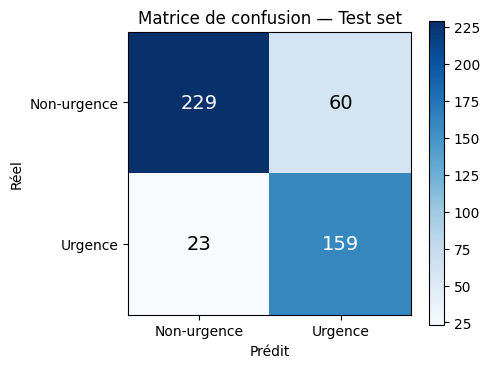

              precision    recall  f1-score   support

 Non-urgence       0.91      0.79      0.85       289
     Urgence       0.73      0.87      0.79       182

    accuracy                           0.82       471
   macro avg       0.82      0.83      0.82       471
weighted avg       0.84      0.82      0.83       471


── Bonus : LR Scheduler CosineAnnealingLR ──


Epochs avec scheduler:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1 Training:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 1 Validation:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 2 Training:   0%|          | 0/45 [00:00<?, ?it/s]

...

Epoch 8 Validation:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 9 Training:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 9 Validation:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 10 Training:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 10 Validation:   0%|          | 0/15 [00:00<?, ?it/s]

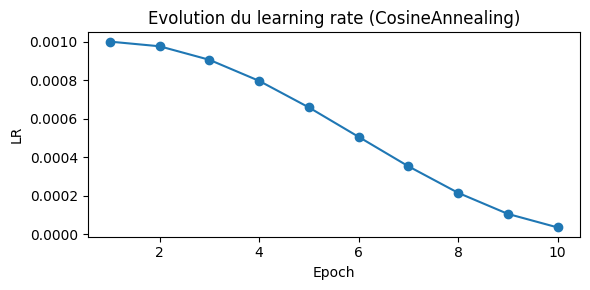

Accuracy test avec scheduler : 0.8577


In [62]:

# Bonus éventuel
from sklearn.metrics import confusion_matrix, classification_report
import torch

print("Calcul de la matrice de confusion sur le jeu de test...\n")

# Réentraîner ou utiliser le modèle déjà entraîné
set_seed(42)
best_model_bonus = SimpleCNN(dropout=0.3).to(device)
optimizer_bonus  = optim.Adam(best_model_bonus.parameters(), lr=1e-3)
loss_fn_bonus    = nn.CrossEntropyLoss()

train_loader_b, val_loader_b, test_loader_b = get_loaders(
    df=labels, image_dir=img_dir, batch_size=32,
    train_idx=train_idx, val_idx=val_idx, test_idx=test_idx,
    train_transform=train_transform, test_transform=test_transform,
)

train_model(best_model_bonus, train_loader_b, val_loader_b, 10,
            optimizer_bonus, loss_fn_bonus, device)

# Prédictions sur le test set
best_model_bonus.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for imgs, tgts in test_loader_b:
        imgs = imgs.to(device)
        preds = best_model_bonus(imgs).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(tgts.numpy())

# Matrice de confusion
cm = confusion_matrix(all_targets, all_preds)
class_names = ["Non-urgence", "Urgence"]

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(class_names); ax.set_yticklabels(class_names)
ax.set_xlabel("Prédit"); ax.set_ylabel("Réel")
ax.set_title("Matrice de confusion — Test set")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=14)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# Rapport de classification
print(classification_report(all_targets, all_preds, target_names=class_names))

# Bonus 2 : LR Scheduler cosine annealing (démonstration)
print("\n── Bonus : LR Scheduler CosineAnnealingLR ──")
model_sched = SimpleCNN(dropout=0.3).to(device)
opt_sched   = optim.Adam(model_sched.parameters(), lr=1e-3)
scheduler   = optim.lr_scheduler.CosineAnnealingLR(opt_sched, T_max=10, eta_min=1e-5)
loss_fn_s   = nn.CrossEntropyLoss()

lrs_recorded = []
for epoch in tqdm(range(1, 11), desc="Epochs avec scheduler"):
    tr_loss, tr_acc, vl_loss, vl_acc = train_validate_epoch(
        epoch, train_loader_b, val_loader_b, model_sched, opt_sched, loss_fn_s, device
    )
    lrs_recorded.append(opt_sched.param_groups[0]['lr'])
    scheduler.step()

plt.figure(figsize=(6, 3))
plt.plot(range(1, 11), lrs_recorded, marker='o')
plt.title("Evolution du learning rate (CosineAnnealing)")
plt.xlabel("Epoch"); plt.ylabel("LR")
plt.tight_layout()
plt.show()

test_acc_sched = evaluate_accuracy(model_sched, test_loader_b, device)
print(f"Accuracy test avec scheduler : {test_acc_sched:.4f}")
